This notebook outlines a pipeline to extract and analyze a variety of **domain-specific features** from a histopathology dataset of four mycetoma species. It uses images pre-processed with **Macenko stain normalization**.

The pipeline focuses on several key feature categories to quantify and characterize the tissue images:

* **Morphological Features:** These features describe the size and shape of objects in the image. They provide information about the structure and geometry of the mycetoma grains, which are essential for classification.
* **Color/Intensity Features:** This category includes features that describe the color and intensity of the pixels. These features are critical to distinguish different mycetoma species, as they can have unique staining properties.
* **Texture Features:** Texture features quantify the patterns and spatial arrangement of colors or intensities within an image. They provide insights into the internal structure of the mycetoma grains and their surrounding tissue.
* **Statistical Features:** These features describe the distribution and moments of pixel intensity values, such as mean, standard deviation, and kurtosis.
* **Structural Features:** This category focuses on the spatial arrangement and relationships between different components of the tissue.

After extracting these features, the notebook uses techniques like **UMAP** and **t-SNE** to reduce the data's dimensionality and visualize the different mycetoma species. This process helps determine if the extracted features are effective at separating the different classes. The final output of this notebook is a CSV file that contains the extracted features. This file can then be used to train various machine learning classifiers such as **Support Vector Machines (SVMs)**, **Random Forests**, or **Gradient Boosting Machines**, which are common approaches for classification tasks based on engineered features.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install umap-learn


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from skimage import measure, color, feature
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.color import rgb2gray
from skimage.io import imread
from skimage.filters import threshold_otsu
from sklearn.preprocessing import StandardScaler

In [ ]:
# Define paths
dataset_path = '/content/drive/MyDrive/MACENKO/'
classes = ['actionmadureapelletrii', 'falciformisporasenegalensis', 'madurellamycetomatis', 'streptomycessomaliesnis']

In [ ]:
# Define class mapping
class_mapping = {
    "actionmadureapelletrii": "AP",
    "falciformisporasenegalensis": "FS",
    "madurellamycetomatis": "MM",
    "streptomycessomaliesnis": "SS"
}

In [ ]:
# Morphological Features
def extract_morphological_features(binary):
    area = np.sum(binary)
    props = measure.regionprops_table(measure.label(binary), properties=('area', 'perimeter', 'eccentricity'))
    perimeter = props['perimeter'][0]
    circularity = 4 * np.pi * (area / (perimeter ** 2)) if perimeter > 0 else 0
    return [area, perimeter, circularity]

In [ ]:
# Color and Intensity Features
def extract_color_intensity_features(img, gray):
    mean_intensity = np.mean(gray)
    median_intensity = np.median(gray)
    intensity_variance = np.var(gray)
    mean_rgb = np.mean(img, axis=(0, 1))
    return [mean_intensity, median_intensity, intensity_variance, *mean_rgb]


In [ ]:
# Texture Features
def extract_texture_features(gray):
    glcm = graycomatrix((gray * 255).astype(np.uint8), [5], [0], 256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]

    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_hist = np.histogram(lbp, bins=np.arange(0, lbp.max() + 1), density=True)[0]
    return [contrast, correlation, energy, *lbp_hist]


In [ ]:
# Statistical Features
def extract_statistical_features(gray):
    mean_intensity_gray = np.mean(gray)
    std_intensity = np.std(gray)
    skewness = np.mean((gray - mean_intensity_gray) ** 3) / (std_intensity ** 3)
    kurtosis = np.mean((gray - mean_intensity_gray) ** 4) / (std_intensity ** 4)
    return [mean_intensity_gray, std_intensity, skewness, kurtosis]


In [ ]:
# Structural and Spatial Features
def extract_structural_features(binary):
    area = np.sum(binary)
    perimeter = measure.perimeter(binary)
    cell_density = area / np.prod(binary.shape)
    perimeter_density = perimeter / np.prod(binary.shape)
    return [cell_density, perimeter_density]


In [ ]:
# Combine features for each image
def extract_all_features(image_path):
    img = imread(image_path)
    gray = rgb2gray(img)
    thresh = threshold_otsu(gray)
    binary = gray > thresh

    morphological_features = extract_morphological_features(binary)
    color_intensity_features = extract_color_intensity_features(img, gray)
    texture_features = extract_texture_features(gray)
    statistical_features = extract_statistical_features(gray)
    structural_features = extract_structural_features(binary)

    return morphological_features, color_intensity_features, texture_features, statistical_features, structural_features


In [ ]:
# Process dataset and create feature matrices
morph_features, color_features, texture_features, stat_features, struct_features = [], [], [], [], []
labels = []
original_labels = []  # To store original labels before mapping

for label in classes:
    class_path = os.path.join(dataset_path, label)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        morph, color, texture, stat, struct = extract_all_features(image_path)
        morph_features.append(morph)
        color_features.append(color)
        texture_features.append(texture)
        stat_features.append(stat)
        struct_features.append(struct)
        original_labels.append(label)
        labels.append(class_mapping[label])  # Use mapped labels for visualization

/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

In [ ]:
# Convert to DataFrames
morph_df = pd.DataFrame(morph_features)
color_df = pd.DataFrame(color_features)
texture_df = pd.DataFrame(texture_features)
stat_df = pd.DataFrame(stat_features)
struct_df = pd.DataFrame(struct_features)

In [ ]:
# Standardize and combine all feature sets
scaler = StandardScaler()
morph_scaled = scaler.fit_transform(morph_df)
color_scaled = scaler.fit_transform(color_df)
texture_scaled = scaler.fit_transform(texture_df)
stat_scaled = scaler.fit_transform(stat_df)
struct_scaled = scaler.fit_transform(struct_df)
all_features_scaled = np.hstack((morph_scaled, color_scaled, texture_scaled, stat_scaled, struct_scaled))


In [ ]:
# Updated Dimensionality Reduction and Visualization function with right-side vertical legend
def plot_dimensionality_reduction(data, labels, title, method='umap'):
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, n_iter=1000)
    else:
        raise ValueError("Method should be 'umap' or 'tsne'")

    embedding = reducer.fit_transform(data)

    # Create figure with adjusted layout to accommodate legend on the right
    plt.figure(figsize=(6, 4))

    # Plot the data
    for i, label in enumerate(np.unique(labels)):
        idx = np.where(np.array(labels) == label)
        plt.scatter(embedding[idx, 0], embedding[idx, 1], label=label, s=20)

    # Set title with larger font
    plt.title(f'{title} - {method.upper()}', fontsize=16, pad=20)

    # Set axis labels with larger font
    plt.xlabel('', fontsize=14)
    plt.ylabel('', fontsize=14)

    # Adjust tick parameters
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Place legend vertically on the right side of the plot
    plt.legend(
        loc='center left',          # Position legend at center left
        bbox_to_anchor=(1.05, 0.5), # Move legend to the right of the plot
        borderaxespad=0.,           # Remove padding around legend
        frameon=False,              # Remove legend frame
        fontsize=12,                # Set legend font size
        markerscale=1.5             # Increase marker size in legend
    )

    # Adjust layout to prevent legend from being cut off
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave 15% space on the right for legend
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


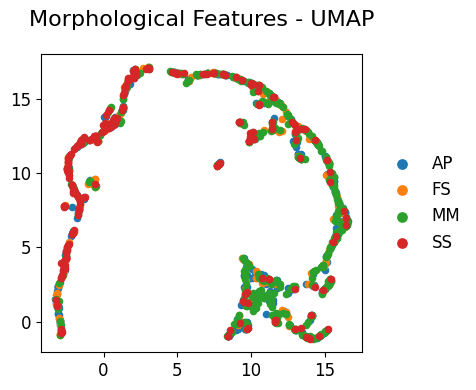

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


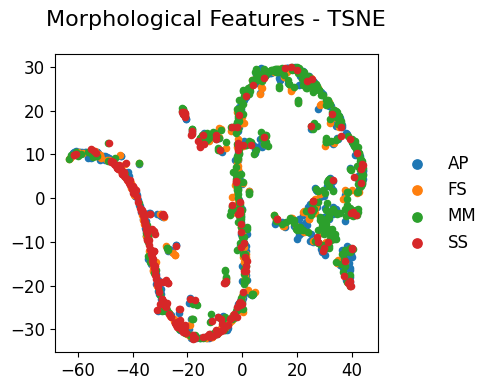

In [ ]:
# Visualize each feature set with new styling
plot_dimensionality_reduction(morph_scaled, labels, 'Morphological Features', method='umap')
plot_dimensionality_reduction(morph_scaled, labels, 'Morphological Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


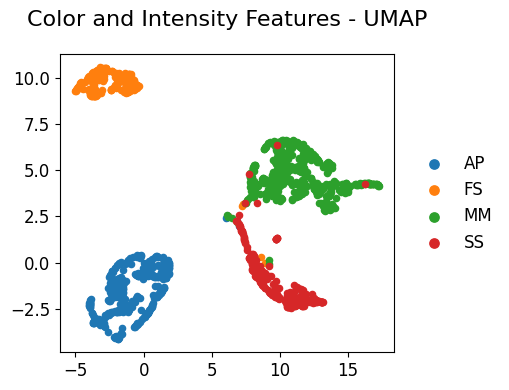

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


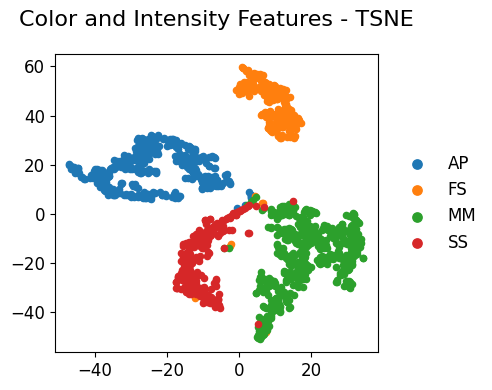

In [ ]:
plot_dimensionality_reduction(color_scaled, labels, 'Color and Intensity Features', method='umap')
plot_dimensionality_reduction(color_scaled, labels, 'Color and Intensity Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


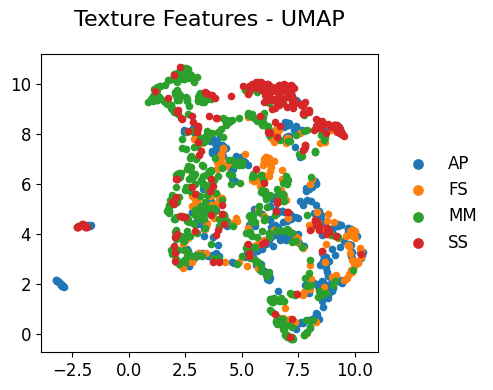

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


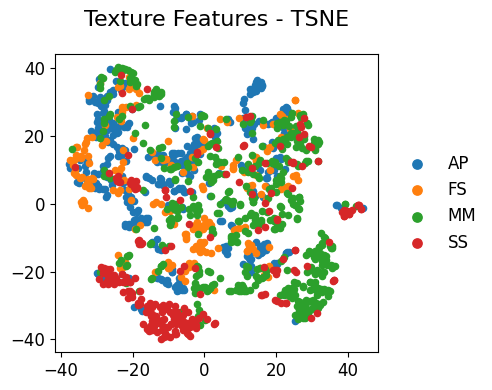

In [ ]:

plot_dimensionality_reduction(texture_scaled, labels, 'Texture Features', method='umap')
plot_dimensionality_reduction(texture_scaled, labels, 'Texture Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


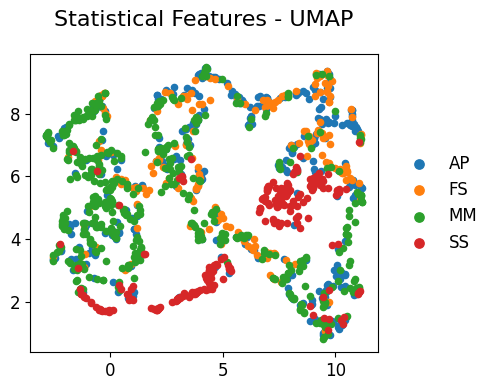

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


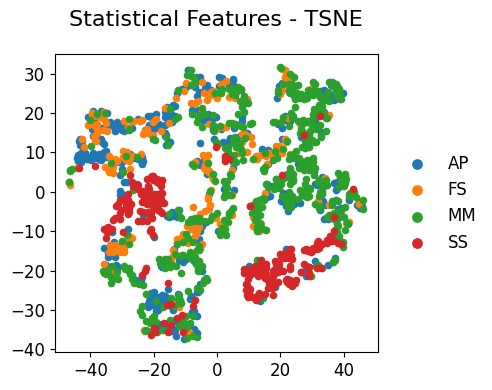

In [ ]:

plot_dimensionality_reduction(stat_scaled, labels, 'Statistical Features', method='umap')
plot_dimensionality_reduction(stat_scaled, labels, 'Statistical Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


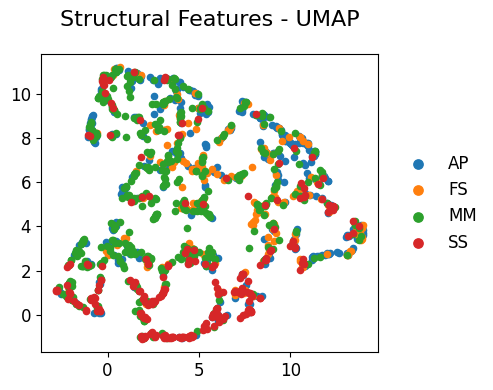

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


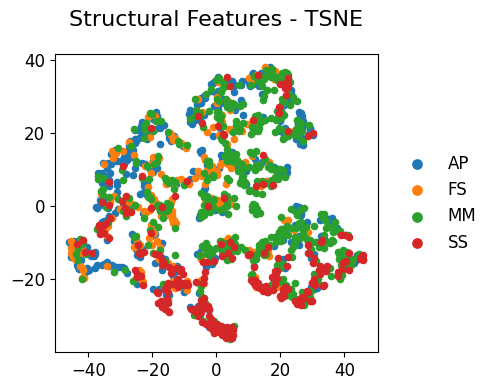

In [ ]:
plot_dimensionality_reduction(struct_scaled, labels, 'Structural Features', method='umap')
plot_dimensionality_reduction(struct_scaled, labels, 'Structural Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


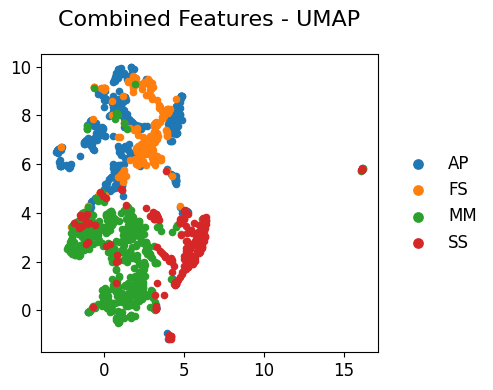

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


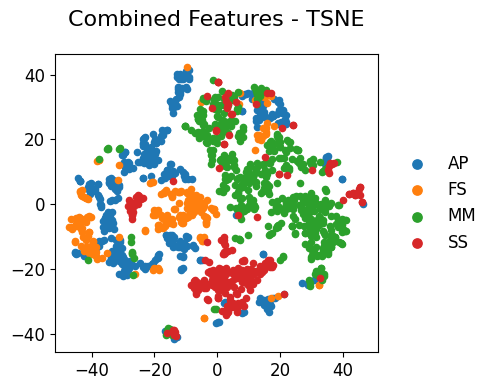

In [ ]:
# Visualize combined features
plot_dimensionality_reduction(all_features_scaled, labels, 'Combined Features', method='umap')
plot_dimensionality_reduction(all_features_scaled, labels, 'Combined Features', method='tsne')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


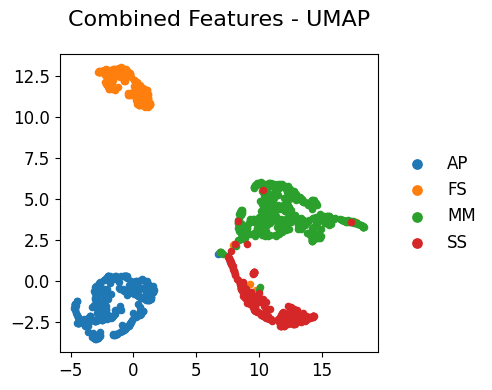

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


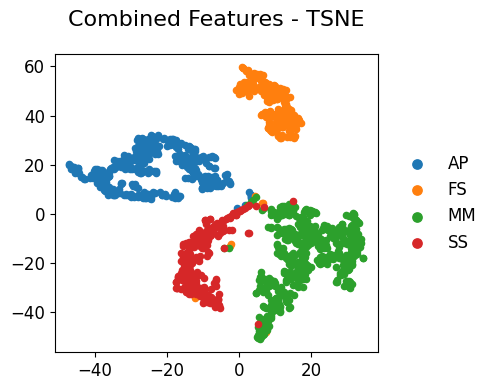

In [ ]:
plot_dimensionality_reduction(color_scaled, labels, 'Combined Features', method='umap')
plot_dimensionality_reduction(color_scaled, labels, 'Combined Features', method='tsne')

In [ ]:
morph_df.head(25)

,0,1,2
0,709203,4.000000,557006.733676
1,471915,26.278175,8587.826430
2,1170280,103.461941,1373.847113
3,912741,64.556349,2752.196887
4,683991,10.621320,76190.923252
5,897091,538.345238,38.897762
6,1119969,113.491378,1092.672787
7,1085605,0.000000,0.000000
8,461483,2352.487553,1.047878
9,541872,21.828427,14290.969359


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 104   0]
 [  0   0   3  46]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       1.00      1.00      1.00        38
          MM       0.97      1.00      0.99       104
          SS       1.00      0.94      0.97        49

    accuracy                           0.99       265
   macro avg       0.99      0.98      0.99       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 98.87%


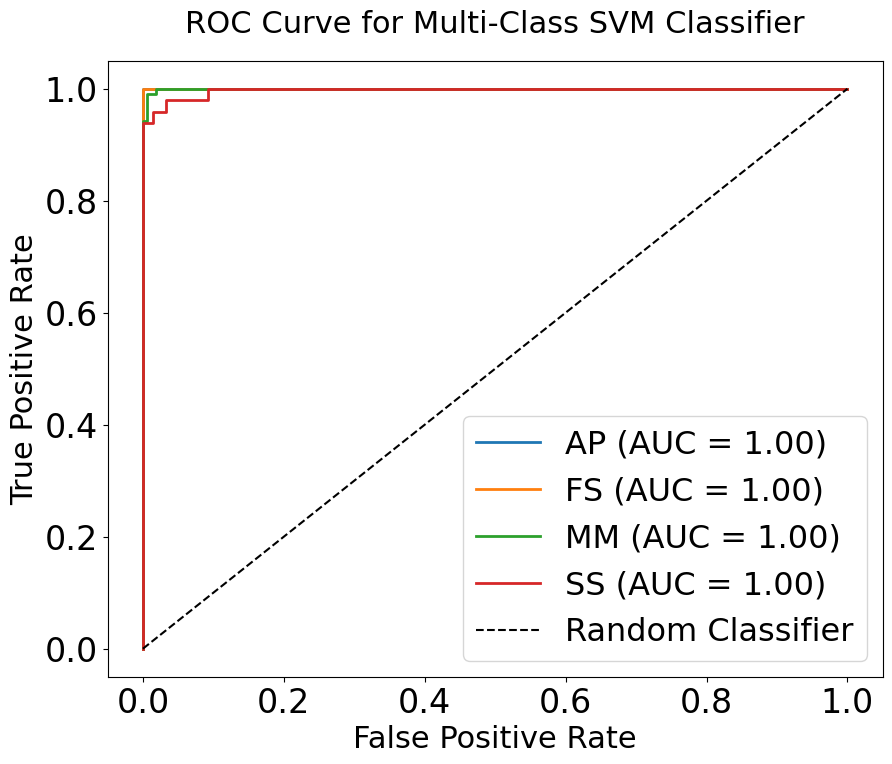

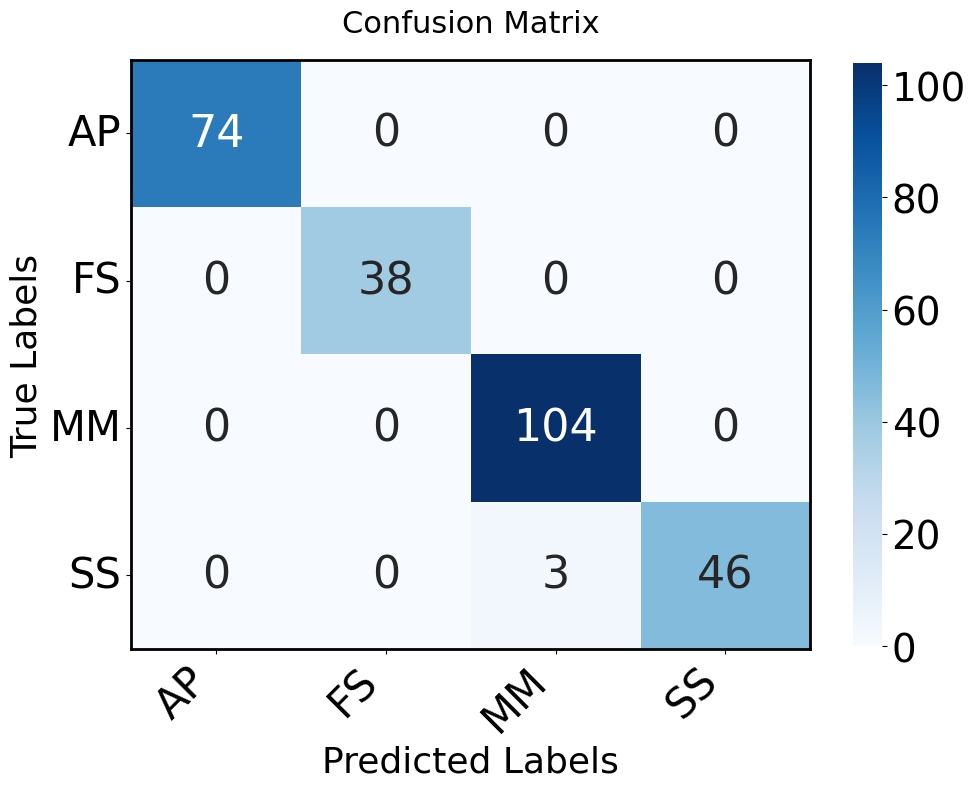

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the SVM classifier (OneVsRest for multi-class classification)
svm_classifier = OneVsRestClassifier(SVC(kernel='linear', probability=True))  # Using linear kernel for simplicity
svm_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, svm_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class SVM Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 103   1]
 [  1   2   0  46]]

Classification Report:
              precision    recall  f1-score   support

          AP       0.99      1.00      0.99        74
          FS       0.95      1.00      0.97        38
          MM       1.00      0.99      1.00       104
          SS       0.98      0.94      0.96        49

    accuracy                           0.98       265
   macro avg       0.98      0.98      0.98       265
weighted avg       0.99      0.98      0.98       265


Accuracy: 98.49%


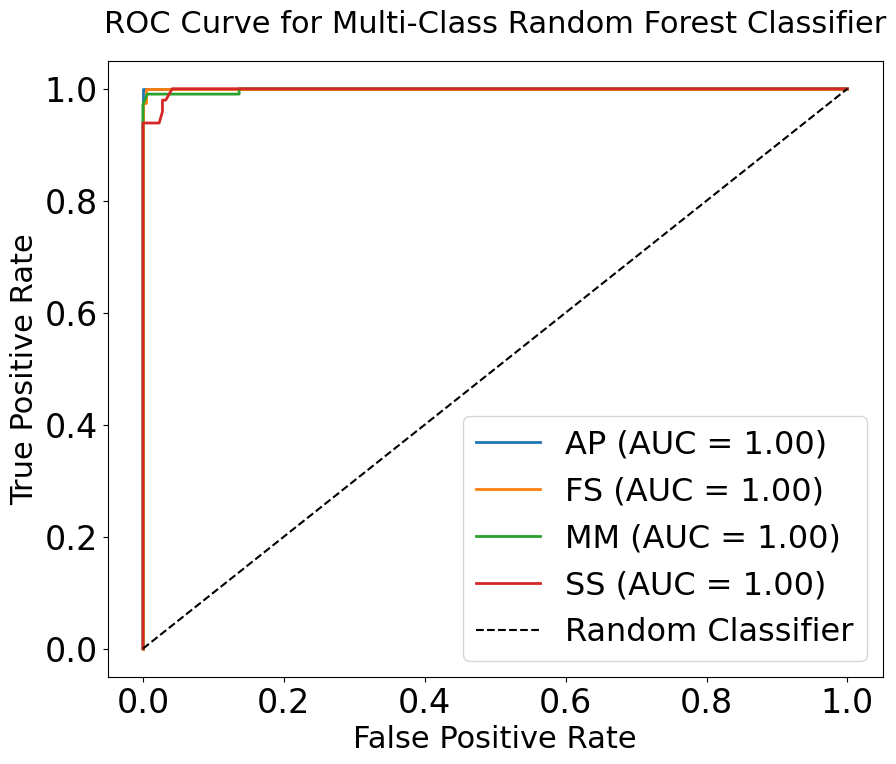

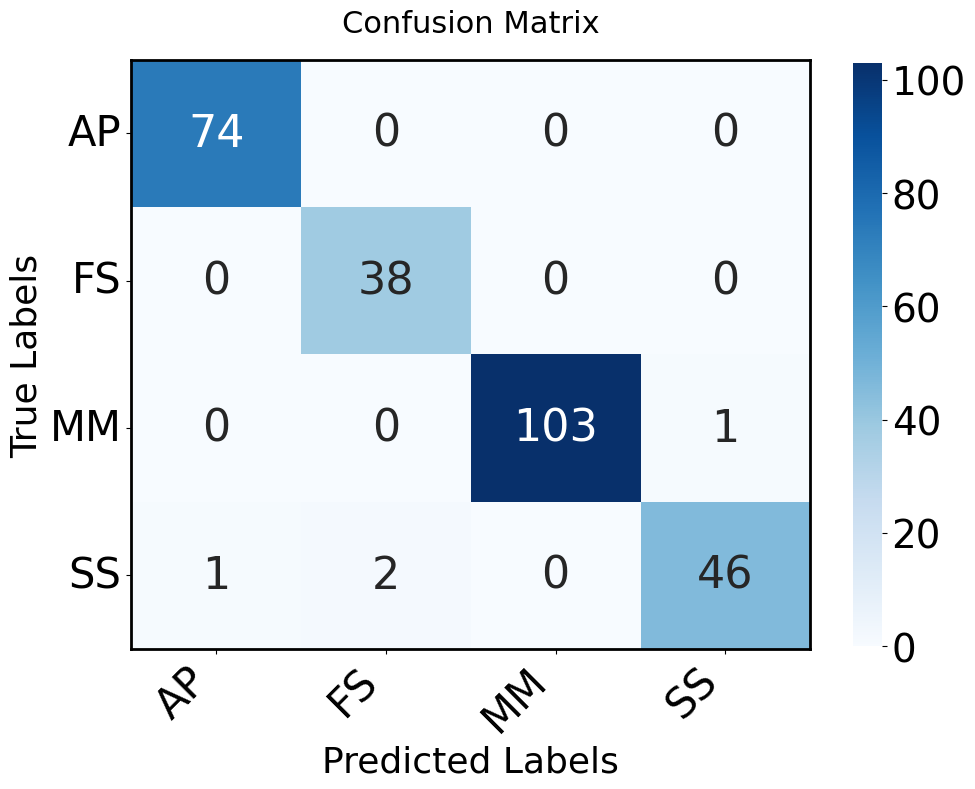

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust the n_estimators parameter
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, rf_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Random Forest Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()




/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 104   0]
 [  0   0   3  46]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       1.00      1.00      1.00        38
          MM       0.97      1.00      0.99       104
          SS       1.00      0.94      0.97        49

    accuracy                           0.99       265
   macro avg       0.99      0.98      0.99       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 98.87%


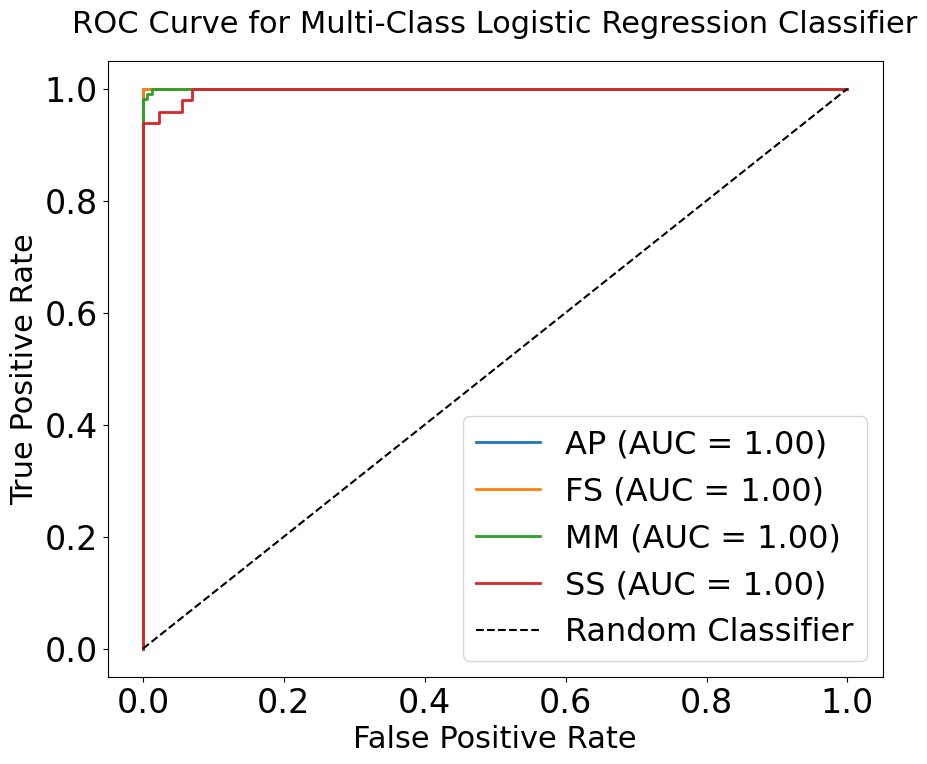

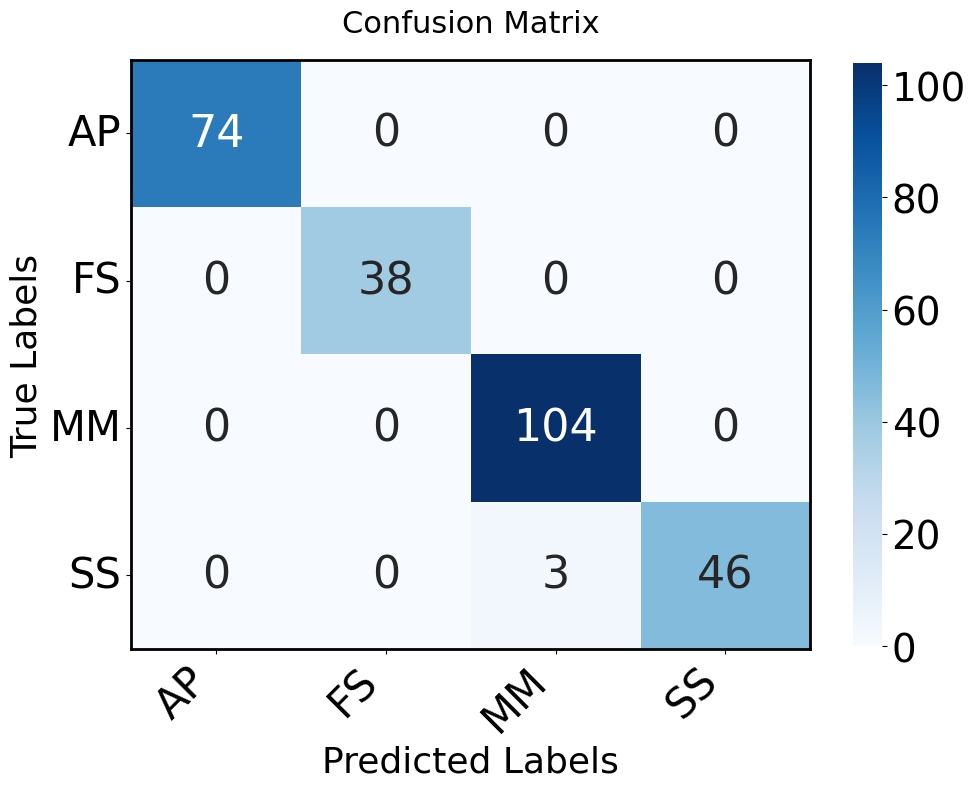

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression classifier
log_reg_classifier = LogisticRegression(max_iter=200, multi_class='ovr', solver='liblinear')  # One-vs-Rest for multi-class
log_reg_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, log_reg_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Logistic Regression Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:16:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 103   1]
 [  0   1   1  47]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       0.97      1.00      0.99        38
          MM       0.99      0.99      0.99       104
          SS       0.98      0.96      0.97        49

    accuracy                           0.99       265
   macro avg       0.99      0.99      0.99       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 98.87%


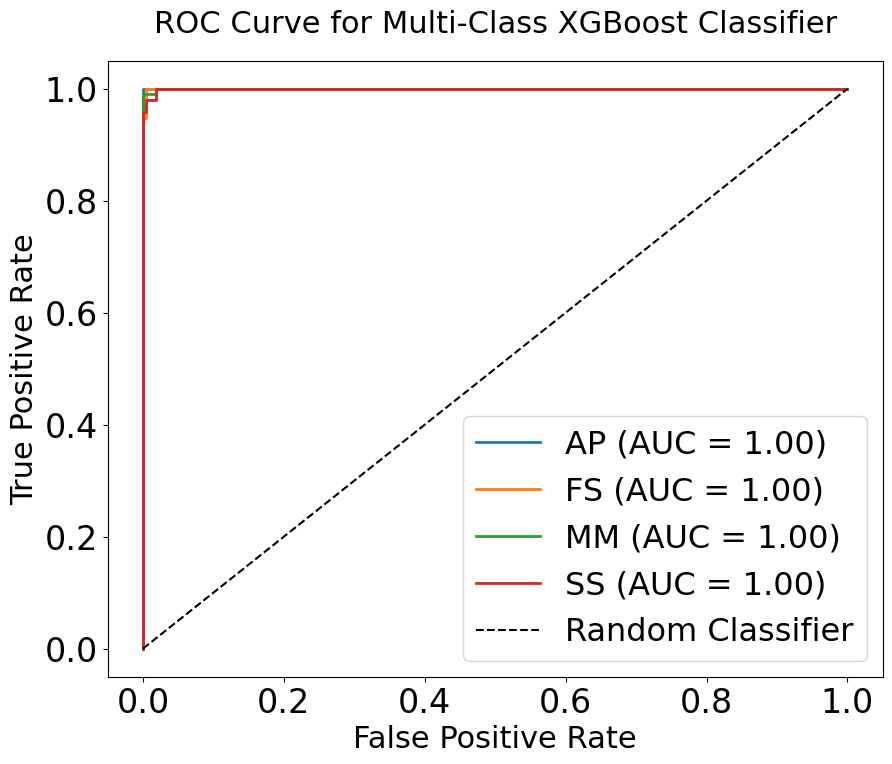

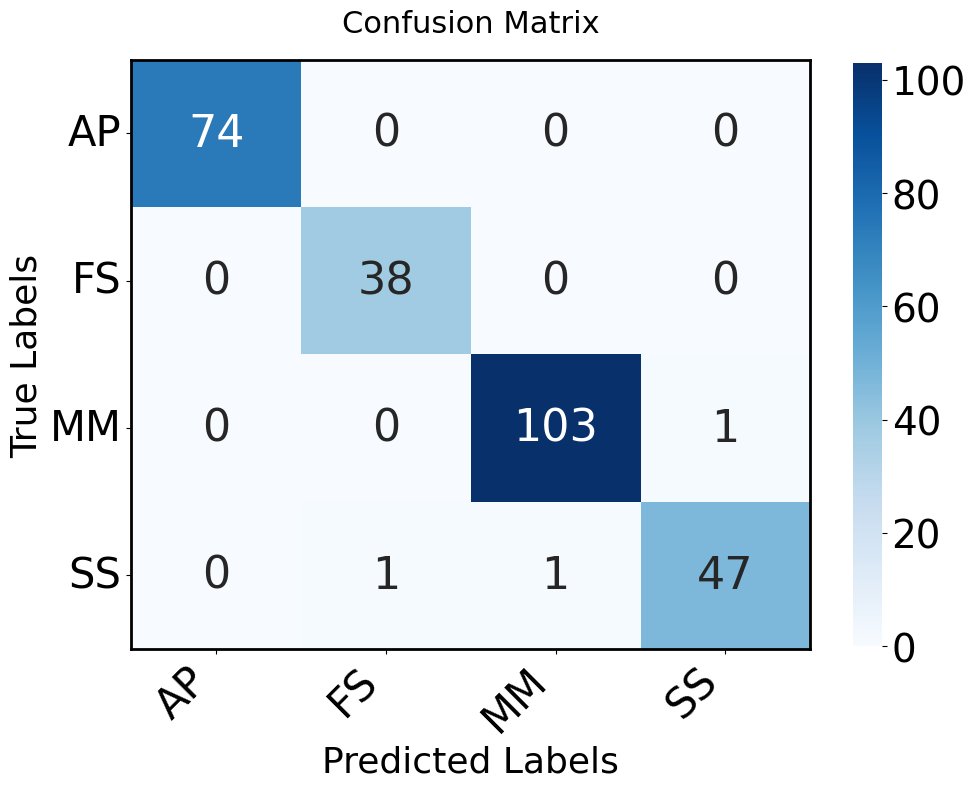

In [ ]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the XGBoost classifier
xgboost_classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', objective='multi:softmax', num_class=len(encoder.classes_))
xgboost_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = xgboost_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, xgboost_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class XGBoost Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()



Confusion Matrix:
[[ 74   0   0   0]
 [  1  36   0   1]
 [  0   1 103   0]
 [  0   1   1  47]]

Classification Report:
              precision    recall  f1-score   support

          AP       0.99      1.00      0.99        74
          FS       0.95      0.95      0.95        38
          MM       0.99      0.99      0.99       104
          SS       0.98      0.96      0.97        49

    accuracy                           0.98       265
   macro avg       0.98      0.97      0.98       265
weighted avg       0.98      0.98      0.98       265


Accuracy: 98.11%


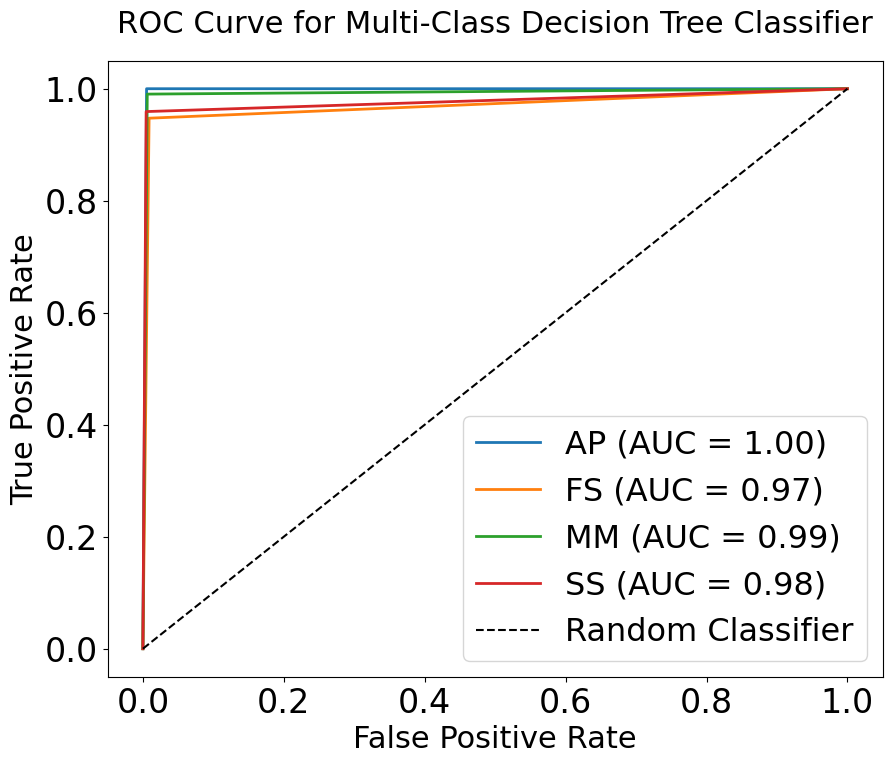

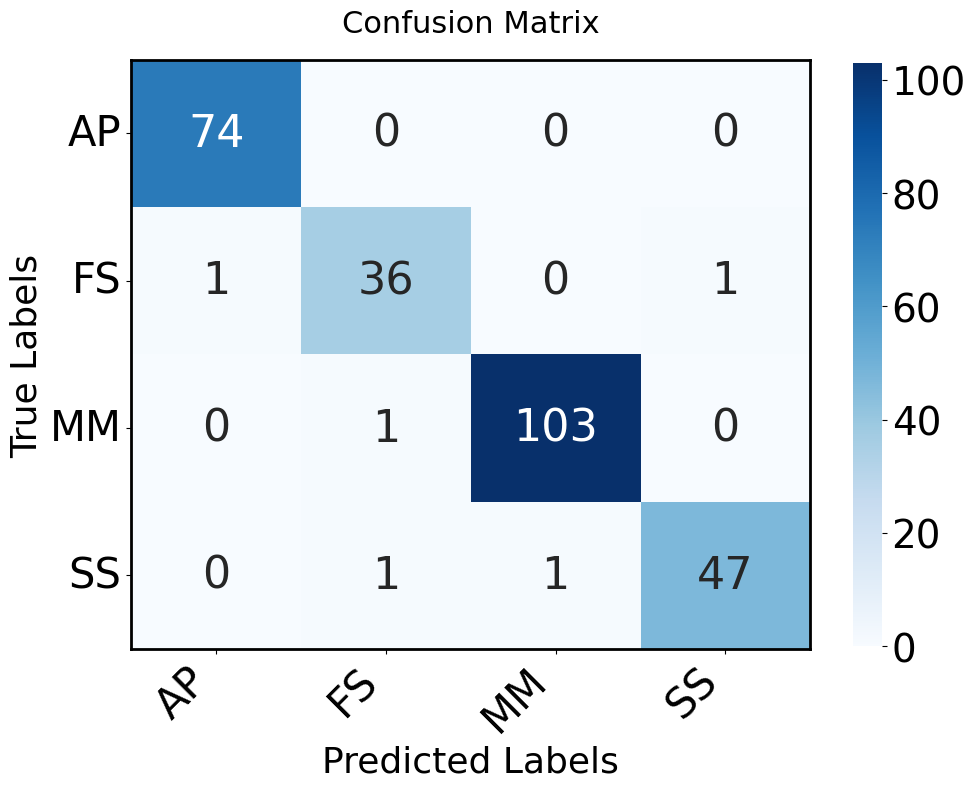

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree classifier
decision_tree_classifier = DecisionTreeClassifier(random_state=42)
decision_tree_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = decision_tree_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, decision_tree_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Decision Tree Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


Confusion Matrix:
[[67  5  0  2]
 [ 2 31  4  1]
 [ 0  3 96  5]
 [ 0  0 11 38]]

Classification Report:
              precision    recall  f1-score   support

          AP       0.97      0.91      0.94        74
          FS       0.79      0.82      0.81        38
          MM       0.86      0.92      0.89       104
          SS       0.83      0.78      0.80        49

    accuracy                           0.88       265
   macro avg       0.86      0.85      0.86       265
weighted avg       0.88      0.88      0.88       265


Accuracy: 87.55%


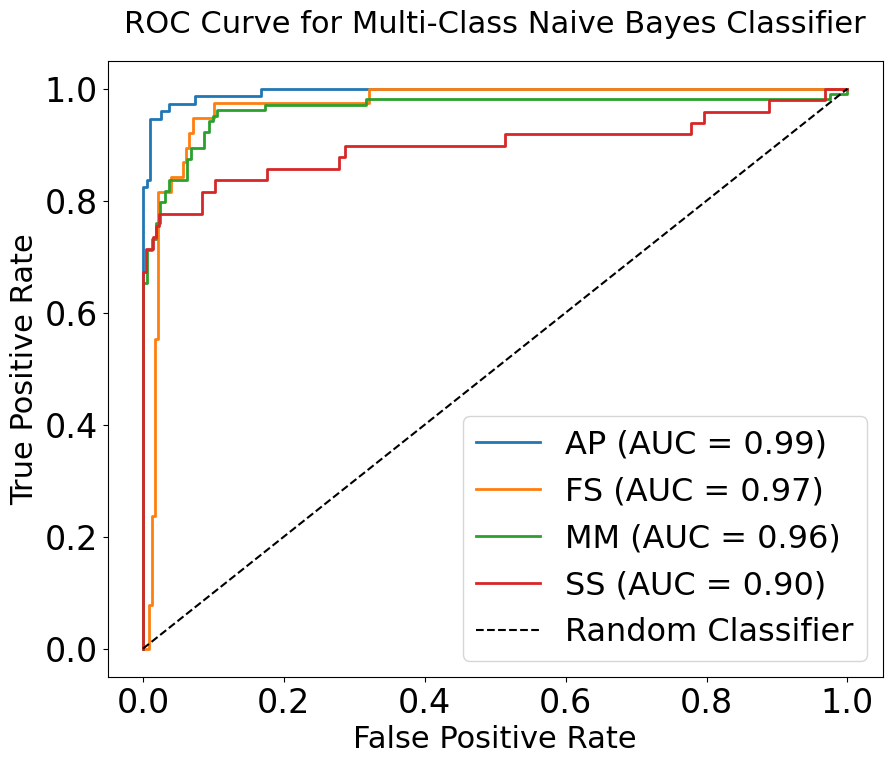

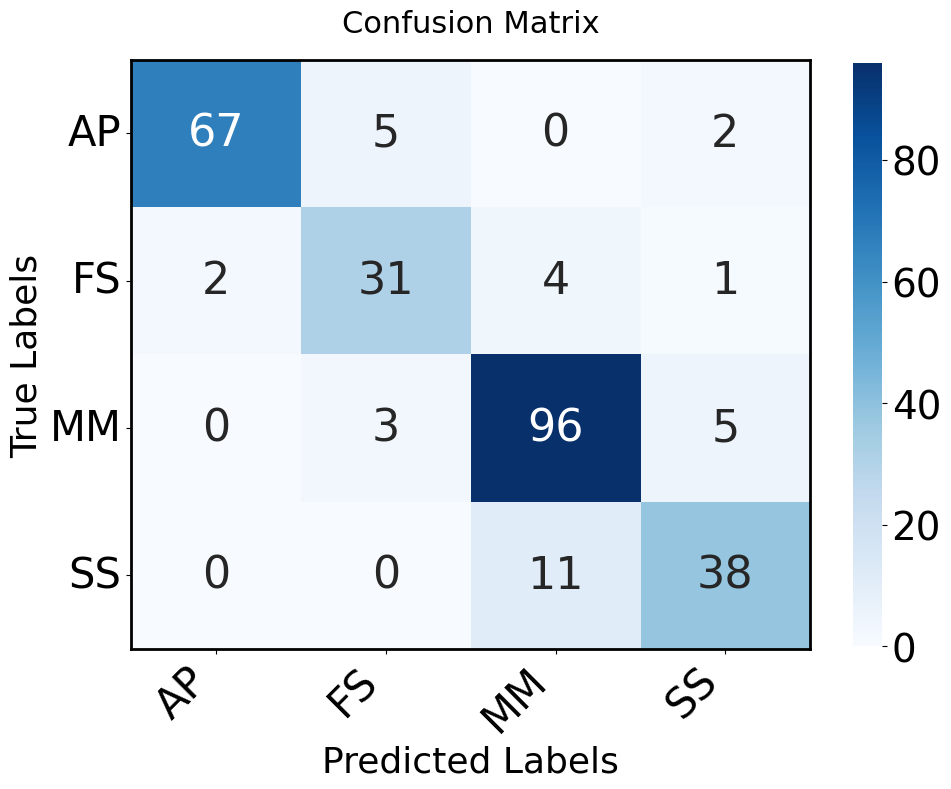

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the Naive Bayes classifier (Gaussian Naive Bayes)
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = nb_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, nb_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Naive Bayes Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 103   1]
 [  0   2   0  47]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       0.95      1.00      0.97        38
          MM       1.00      0.99      1.00       104
          SS       0.98      0.96      0.97        49

    accuracy                           0.99       265
   macro avg       0.98      0.99      0.98       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 98.87%


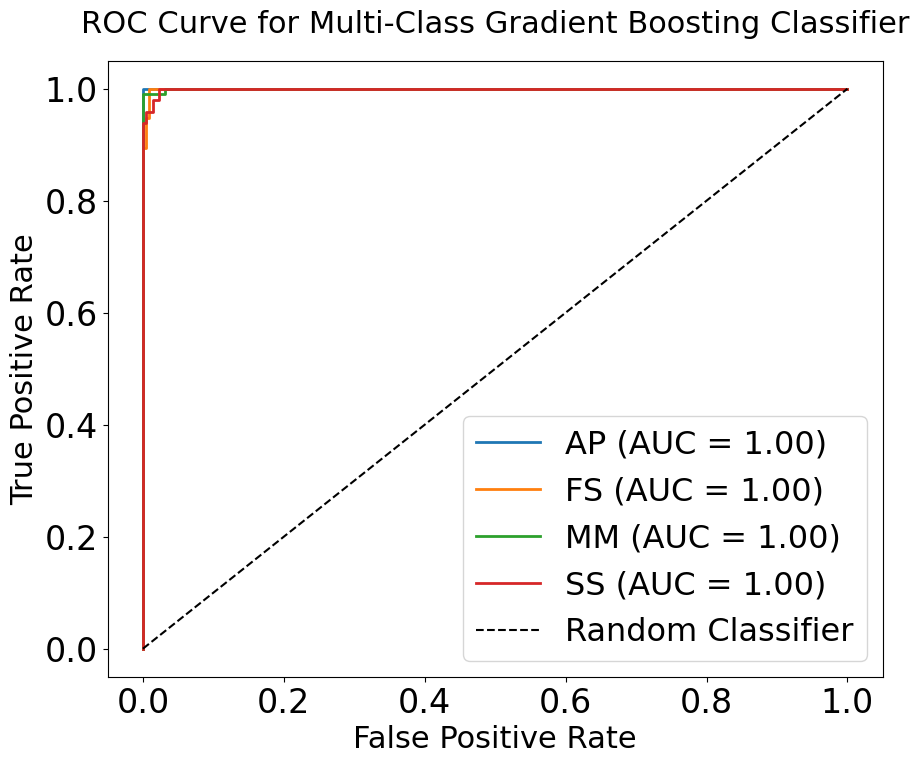

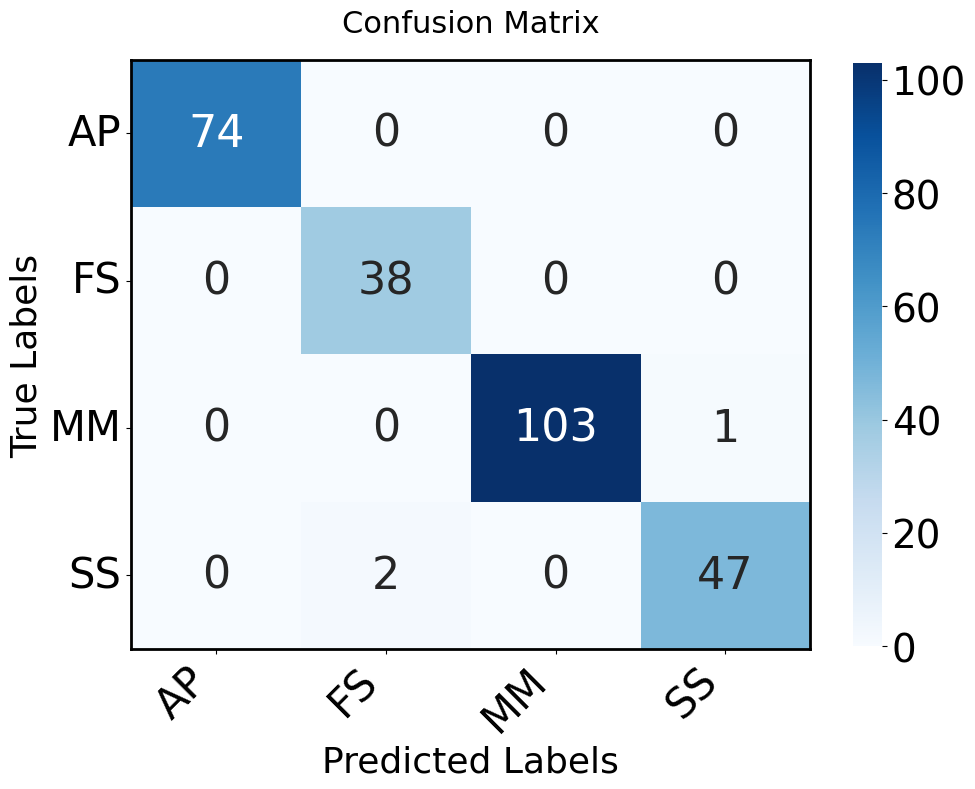

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the Gradient Boosting classifier
gb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = gb_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, gb_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Gradient Boosting Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   1 103   0]
 [  0   0   2  47]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       0.97      1.00      0.99        38
          MM       0.98      0.99      0.99       104
          SS       1.00      0.96      0.98        49

    accuracy                           0.99       265
   macro avg       0.99      0.99      0.99       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 98.87%


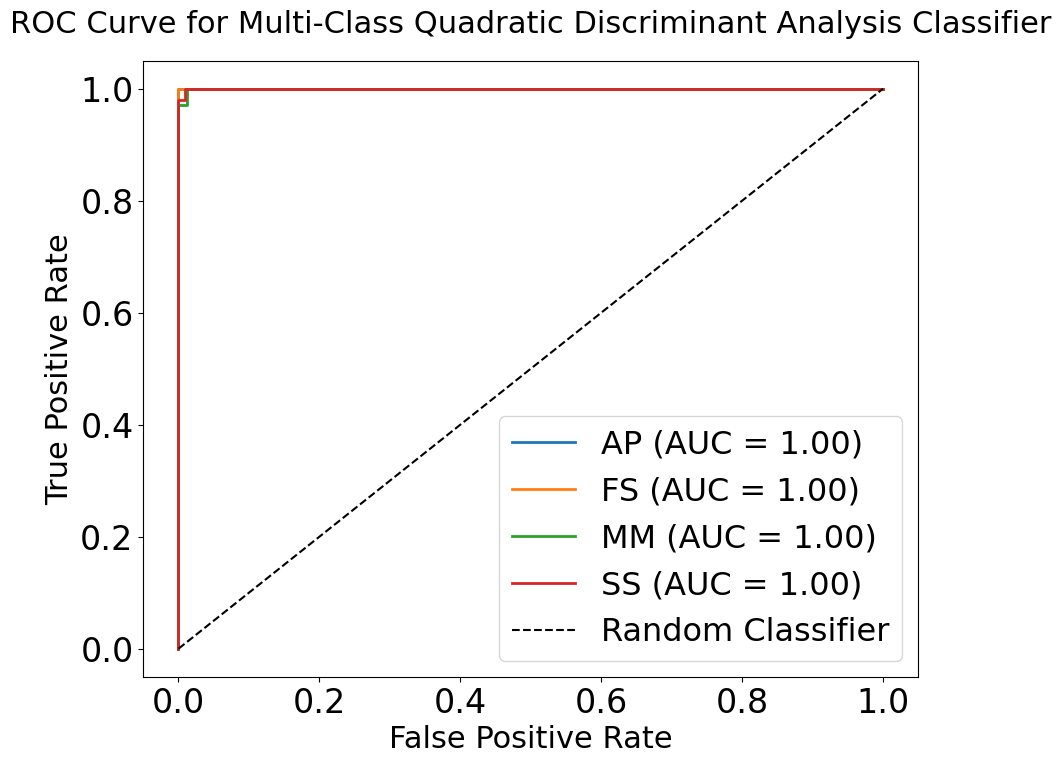

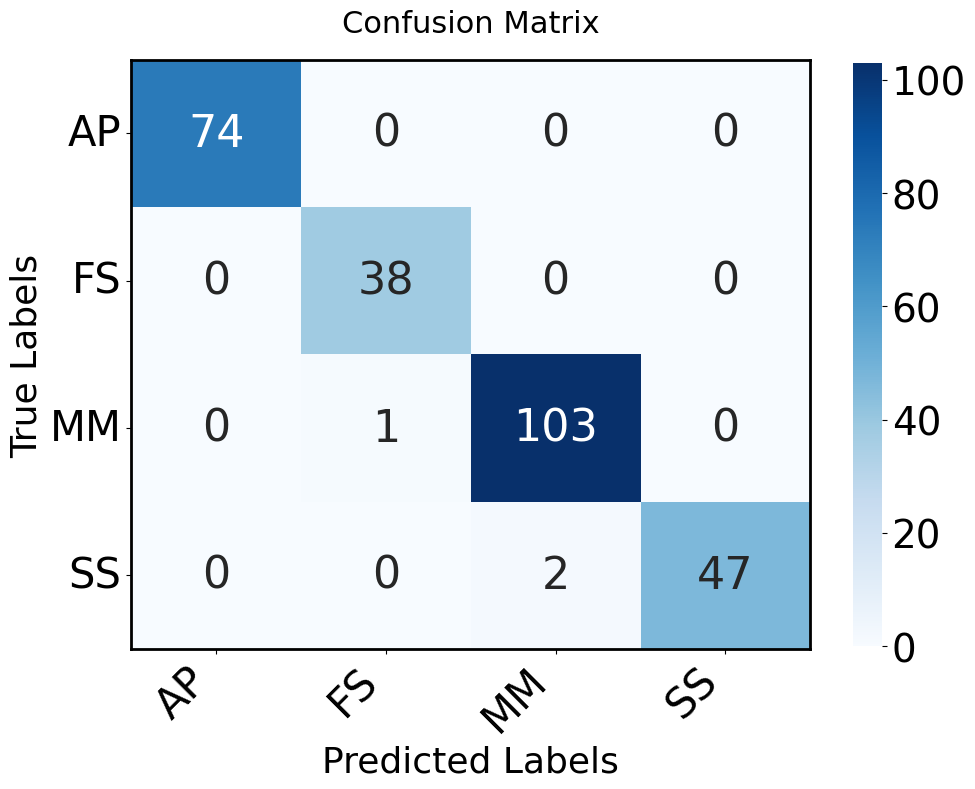

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize the Quadratic Discriminant Analysis (QDA) classifier
qda_classifier = QuadraticDiscriminantAnalysis()

# Train the QDA classifier
qda_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = qda_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, qda_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')


# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Quadratic Discriminant Analysis Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

Confusion Matrix:
[[67  5  0  2]
 [ 2 31  4  1]
 [ 0  3 96  5]
 [ 0  0 11 38]]

Classification Report:
              precision    recall  f1-score   support

          AP       0.97      0.91      0.94        74
          FS       0.79      0.82      0.81        38
          MM       0.86      0.92      0.89       104
          SS       0.83      0.78      0.80        49

    accuracy                           0.88       265
   macro avg       0.86      0.85      0.86       265
weighted avg       0.88      0.88      0.88       265


Accuracy: 87.55%


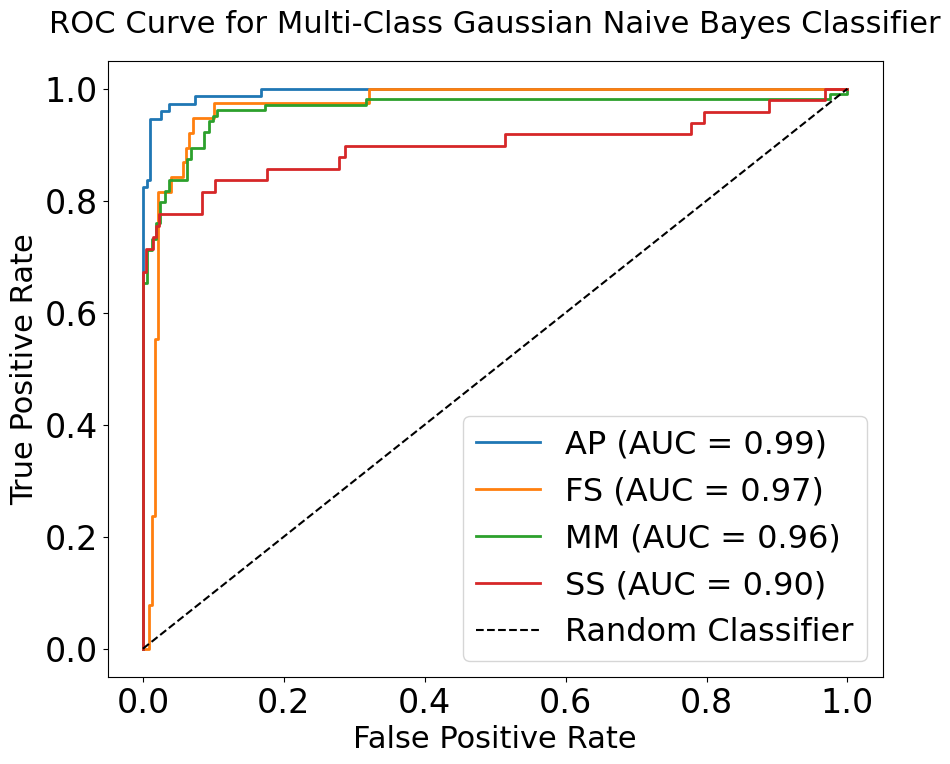

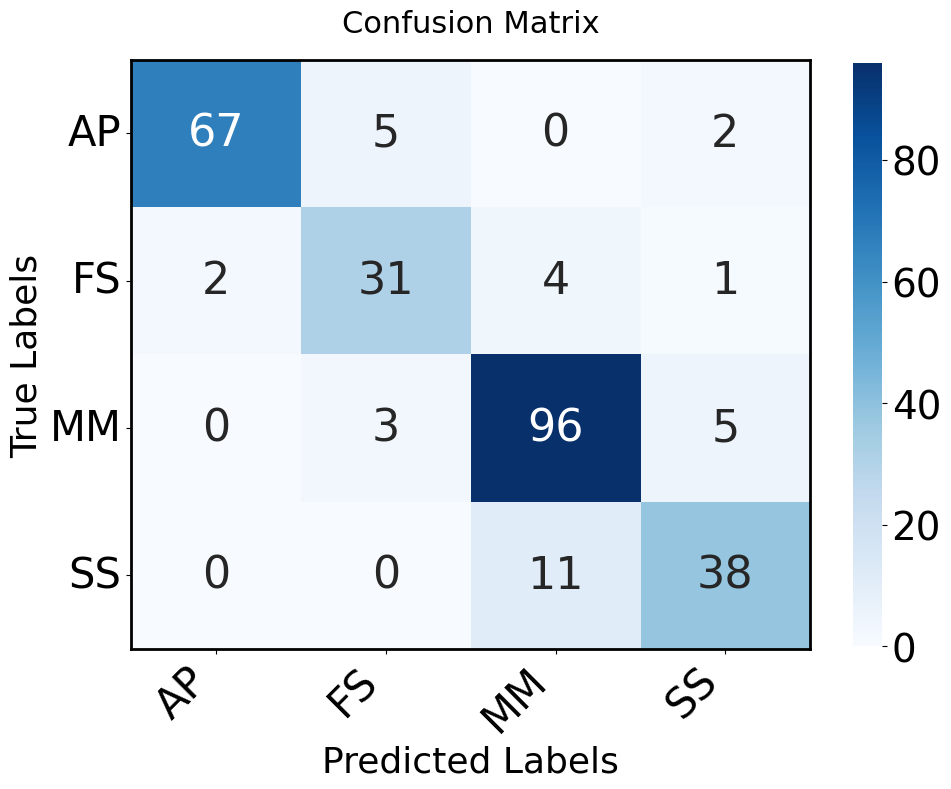

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize the Gaussian Naive Bayes classifier
gnb_classifier = GaussianNB()

# Train the Gaussian Naive Bayes classifier
gnb_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = gnb_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, gnb_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class Gaussian Naive Bayes Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


0:	learn: 1.2011532	total: 93.7ms	remaining: 1m 33s
200:	learn: 0.0209266	total: 8.03s	remaining: 31.9s
400:	learn: 0.0083110	total: 18.1s	remaining: 27.1s
600:	learn: 0.0049964	total: 27.8s	remaining: 18.4s
800:	learn: 0.0035301	total: 36.6s	remaining: 9.08s
999:	learn: 0.0027460	total: 44.9s	remaining: 0us
Confusion Matrix:
[[ 74   0   0   0]
 [  0  38   0   0]
 [  0   0 103   1]
 [  0   1   0  48]]

Classification Report:
              precision    recall  f1-score   support

          AP       1.00      1.00      1.00        74
          FS       0.97      1.00      0.99        38
          MM       1.00      0.99      1.00       104
          SS       0.98      0.98      0.98        49

    accuracy                           0.99       265
   macro avg       0.99      0.99      0.99       265
weighted avg       0.99      0.99      0.99       265


Accuracy: 99.25%


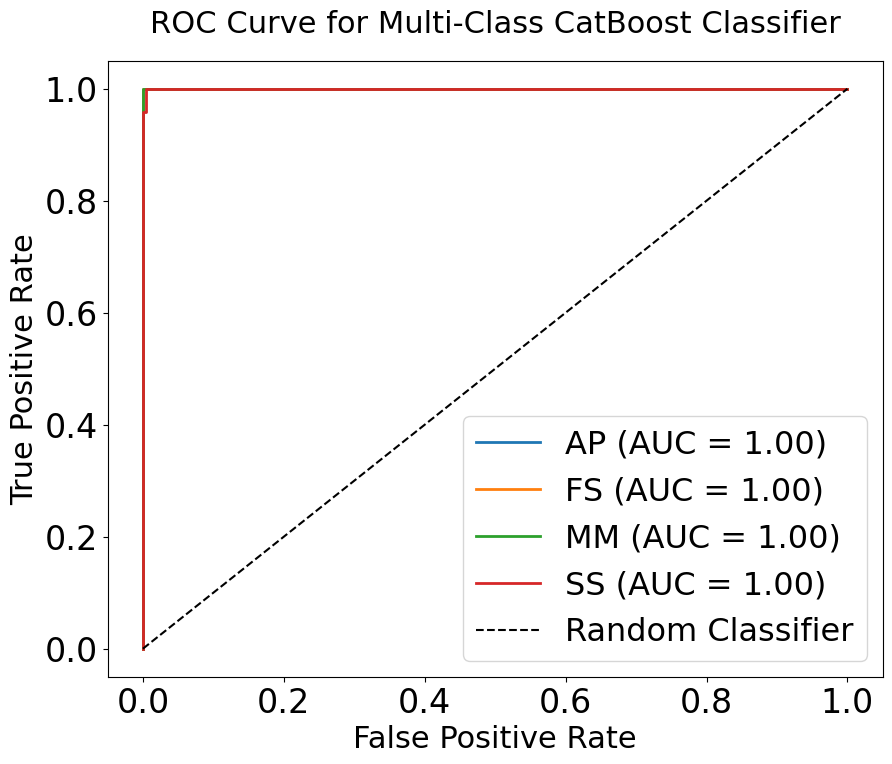

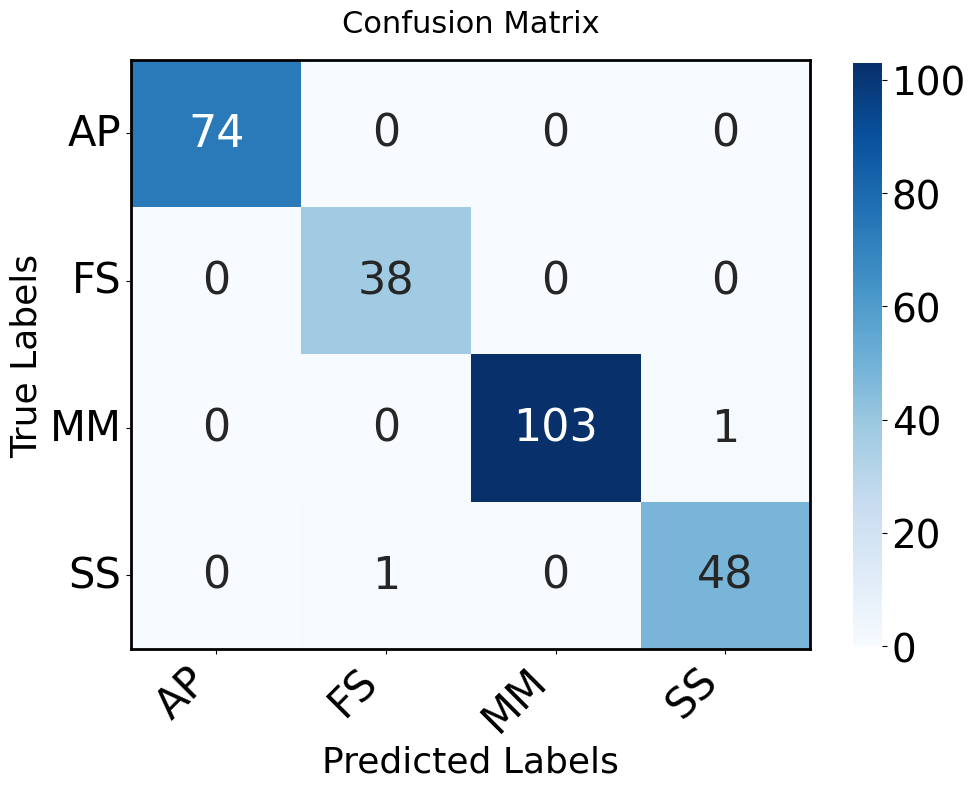

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize the CatBoostClassifier
catboost_classifier = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=200)

# Train the CatBoost classifier
catboost_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = catboost_classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, catboost_classifier.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class CatBoost Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


In [ ]:
pip install scikit-learn matplotlib seaborn


Confusion Matrix:
[[70  1  0  3]
 [ 4 34  0  0]
 [ 4  2 92  6]
 [ 4  0  4 41]]

Classification Report:
              precision    recall  f1-score   support

          AP       0.85      0.95      0.90        74
          FS       0.92      0.89      0.91        38
          MM       0.96      0.88      0.92       104
          SS       0.82      0.84      0.83        49

    accuracy                           0.89       265
   macro avg       0.89      0.89      0.89       265
weighted avg       0.90      0.89      0.89       265


Accuracy: 89.43%


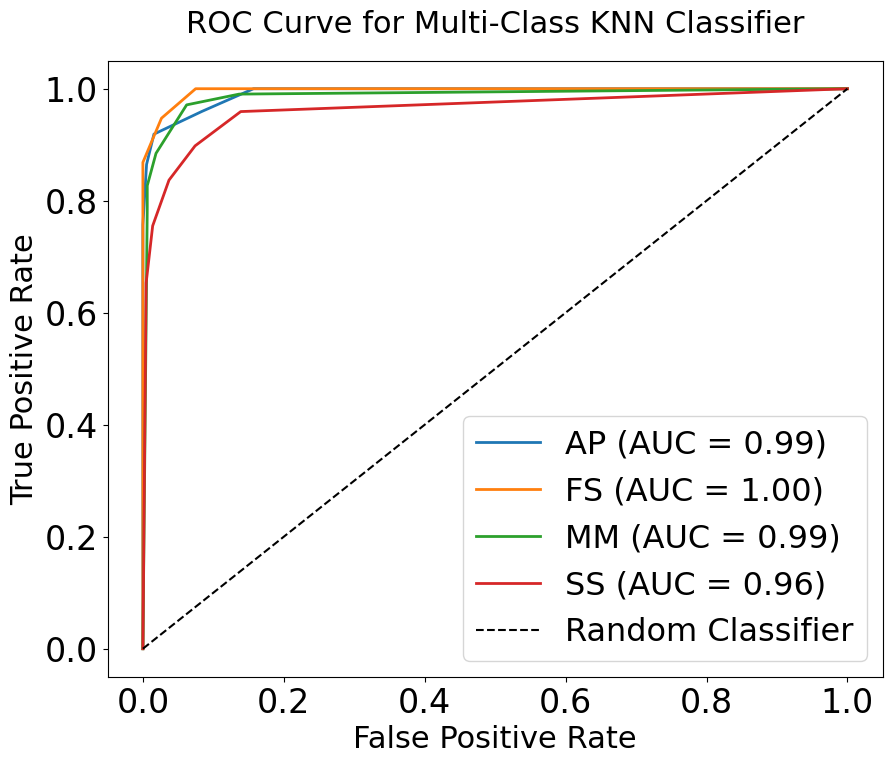

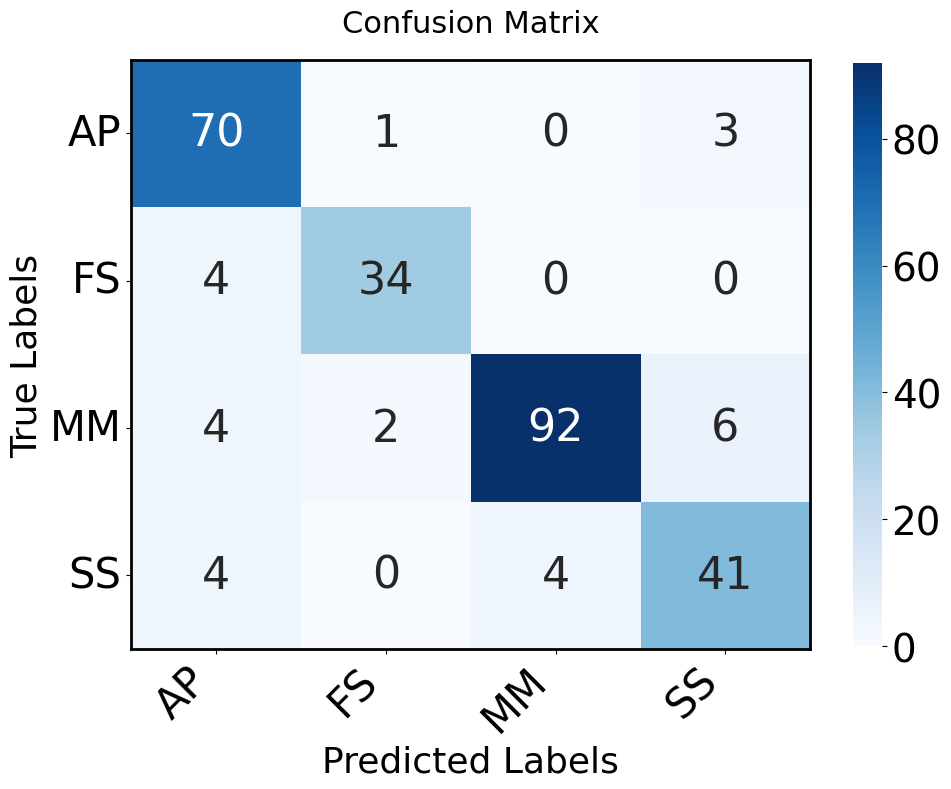

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'all_features_scaled' contains the extracted features and 'labels' contains the corresponding labels

# Prepare labels and features for classification
original_labels = np.array(original_labels)  # Use the original labels before mapping
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(original_labels)  # Encode string labels into numbers
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(all_features_scaled, encoded_labels, test_size=0.2, random_state=42)

# Initialize KNN classifier with k=5 (you can tune 'k' for better performance)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Get mapped class names for display
mapped_classes = [class_mapping[cls] for cls in encoder.classes_]

# Classification Report (Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapped_classes))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ROC Curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, knn.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve with mapped class names
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'{mapped_classes[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot random line (no discrimination)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Customize plot with larger fonts
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('ROC Curve for Multi-Class KNN Classifier', fontsize=22, pad=20)
plt.legend(loc="lower right", fontsize=23)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

# Enhanced Confusion Matrix with mapped classes and larger elements
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=mapped_classes,
                 yticklabels=mapped_classes,
                 annot_kws={"size": 32},# Enlarge the matrix values

                  cbar_kws={"shrink": 0.99,  # Adjust colorbar size
                          "orientation": "vertical",  # Ensure vertical orientation
                          "pad": 0.05,  # Adjust padding
                          "aspect": 20})  # Control aspect ratio

# Get the colorbar object from the heatmap
cbar = ax.collections[0].colorbar

# Set the font size for colorbar tick labels and label
cbar.ax.tick_params(labelsize=28)  # Tick label size
cbar.ax.yaxis.label.set_size(20)  # Colorbar label size (if you have one)
cbar.ax.yaxis.label.set_weight('bold')  # Make label bold if needed


# Customize the confusion matrix plot
plt.title("Confusion Matrix", fontsize=22, pad=20)
plt.ylabel('True Labels', fontsize=26)
plt.xlabel('Predicted Labels', fontsize=26)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=30)

# Add a white grid to separate cells for better readability
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Assuming all_features_scaled is a NumPy array or pandas DataFrame
# Convert the numpy array to a DataFrame if needed
df = pd.DataFrame(all_features_scaled)

# Save to CSV
df.to_csv('extracted_features.csv', index=False)  # Avoid saving row numbers with 'index=False'
print("Features saved as extracted_features-original images.csv")

Features saved as extracted_features-original images.csv
